In [3]:
# ─── Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [9]:
# ─── Load Clean Data ───────────────────────────────────────
# We work from the cleaned CSV — never from raw again
# This is why Day 2 cleaning pipeline matters so much

df = pd.read_csv('C:/Users/DELL/rfm-analysis/data/processed/clean_retail.csv', 
                 parse_dates=['InvoiceDate'])

print(f"Clean data shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
df.head()

Clean data shape: (779425, 9)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers: 5,878


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


In [10]:
# ─── Define Snapshot Date ──────────────────────────────────
# Snapshot date = the reference point for Recency calculation
# Convention: 1 day after the last transaction in the dataset
# WHY: If we use today's date, all customers look equally inactive
# Using the dataset's end date keeps analysis self-contained and reproducible

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")
print(f"Last transaction: {df['InvoiceDate'].max().date()}")

Snapshot date: 2011-12-10
Last transaction: 2011-12-09


In [11]:
# ─── Calculate Raw RFM Values ──────────────────────────────
# Recency   = days since last purchase (lower = better)
# Frequency = number of unique invoices (higher = better)
# Monetary  = total revenue generated (higher = better)
# 
# We use nunique() for frequency — not count()
# WHY: One invoice can have multiple line items
# We want to count TRANSACTIONS not line items

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print(f"\nRFM Summary:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
rfm.head(10)

RFM table shape: (5878, 4)

RFM Summary:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean    201.33       6.29   2621.81
std     209.34      13.01  11041.92
min       1.00       1.00      2.95
25%      26.00       1.00    332.71
50%      96.00       3.00    837.21
75%     380.00       7.00   2160.62
max     739.00     398.00 437763.73


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,522.62
1,12347,2,8,4822.65
2,12348,75,5,1793.95
3,12349,19,4,3612.54
4,12350,310,1,309.35
5,12351,375,1,300.93
6,12352,36,10,1879.04
7,12353,204,2,406.76
8,12354,232,1,1073.40
9,12355,214,2,947.61


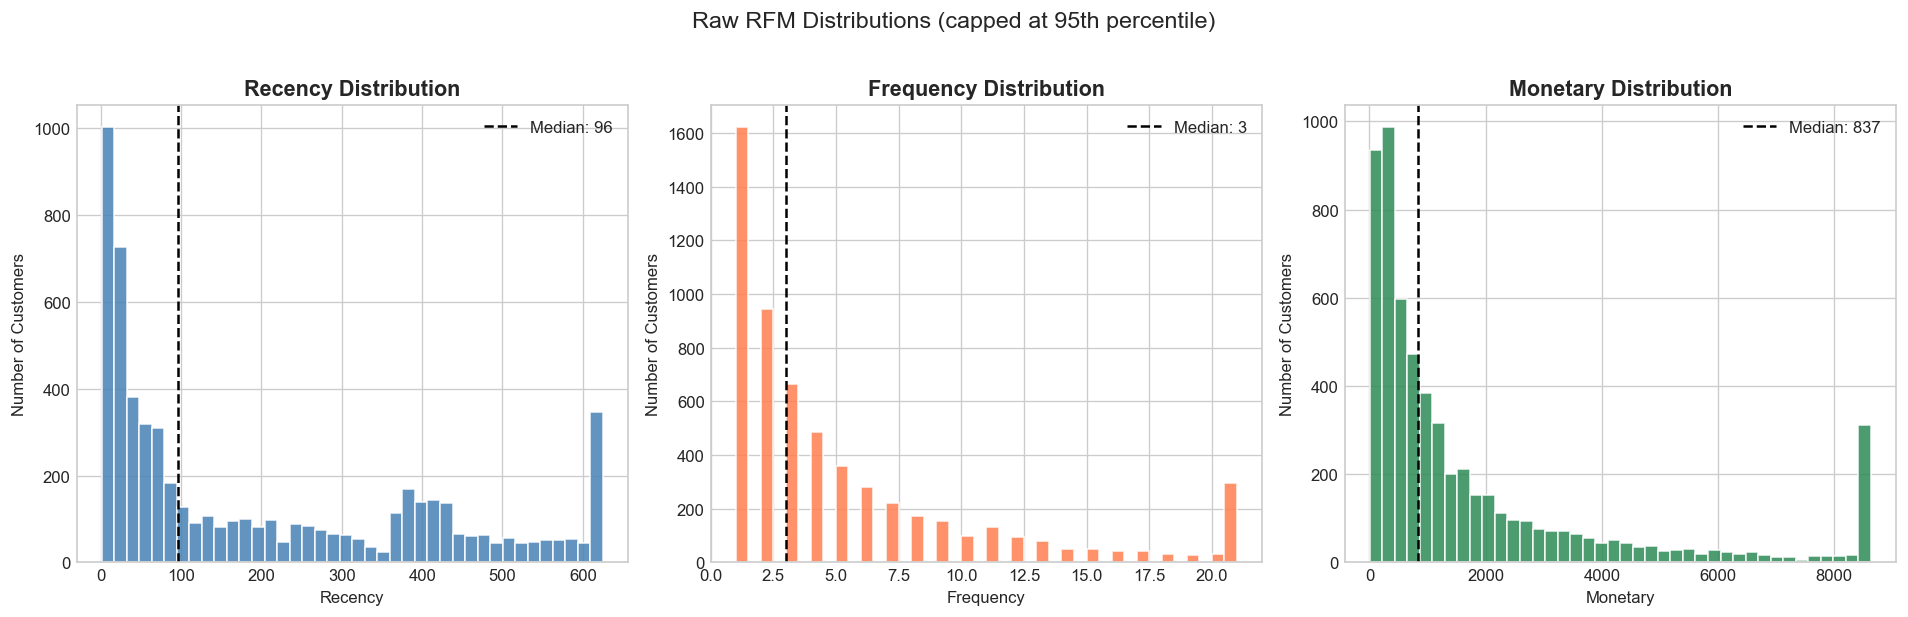

In [21]:
# ─── RFM Distribution Plots ────────────────────────────────
# Before scoring we visualize raw distributions
# This tells us: are they skewed? symmetric? bimodal?
# Skewed distributions are why we use quantile-based scoring
# not equal-interval scoring

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, 
                           ['Recency', 'Frequency', 'Monetary'],
                           ['steelblue', 'coral', 'seagreen']):
    # Cap at 95th percentile for visibility
    data = rfm[col].clip(upper=rfm[col].quantile(0.95))
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of Customers')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', 
               linewidth=1.5, label=f'Median: {rfm[col].median():.0f}')
    ax.legend()

plt.suptitle('Raw RFM Distributions (capped at 95th percentile)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ─── Quantile-Based RFM Scoring ────────────────────────────
# We score each customer 1-5 on each dimension
# WHY quantile-based (not equal intervals)?
# Because data is skewed — equal intervals would put 90% of 
# customers in one bucket
# Quantiles guarantee ~equal customer counts per score bucket
#
# RECENCY: Lower days = better = higher score (REVERSED)
# FREQUENCY: Higher count = better = higher score
# MONETARY: Higher revenue = better = higher score

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, 
                          labels=[5, 4, 3, 2, 1])  # reversed: low recency = high score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, 
                          labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, 
                          labels=[1, 2, 3, 4, 5])

# Convert to int for calculations
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Composite RFM Score (weighted: F and M slightly more important than R)
rfm['RFM_Score'] = (rfm['R_Score'] * 0.3 + 
                    rfm['F_Score'] * 0.35 + 
                    rfm['M_Score'] * 0.35)

# RFM Segment string (e.g. "555", "123")
rfm['RFM_Segment'] = (rfm['R_Score'].astype(str) + 
                       rfm['F_Score'].astype(str) + 
                       rfm['M_Score'].astype(str))

print("Scoring complete!")
print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment']].head(10))

Scoring complete!
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326         12    522.62        2        5        2   
1        12347        2          8   4822.65        5        4        5   
2        12348       75          5   1793.95        3        4        4   
3        12349       19          4   3612.54        5        3        5   
4        12350      310          1    309.35        2        1        2   
5        12351      375          1    300.93        2        1        2   
6        12352       36         10   1879.04        4        5        4   
7        12353      204          2    406.76        2        2        2   
8        12354      232          1   1073.40        2        1        3   
9        12355      214          2    947.61        2        2        3   

   RFM_Score RFM_Segment  
0       3.05         252  
1       4.65         545  
2       3.70         344  
3       4.30         535  
4       1.65         

In [16]:
# ─── Customer Segmentation Labels ──────────────────────────
# We map RFM scores to business-meaningful segment names
# These labels are what make the analysis actionable
# A marketing team can act on "At Risk" — not on "Score: 2.1"

def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r == 3 and f == 1 and m == 1:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'Need Attention'
    elif r == 1 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segment distribution:")
print(rfm['Segment'].value_counts())
print(f"\nTotal customers: {len(rfm):,}")

Segment distribution:
Segment
Champions              1299
Loyal Customers        1139
Hibernating             704
Lost                    645
At Risk                 620
Need Attention          575
Recent Customers        443
Potential Loyalists     358
Promising                95
Name: count, dtype: int64

Total customers: 5,878


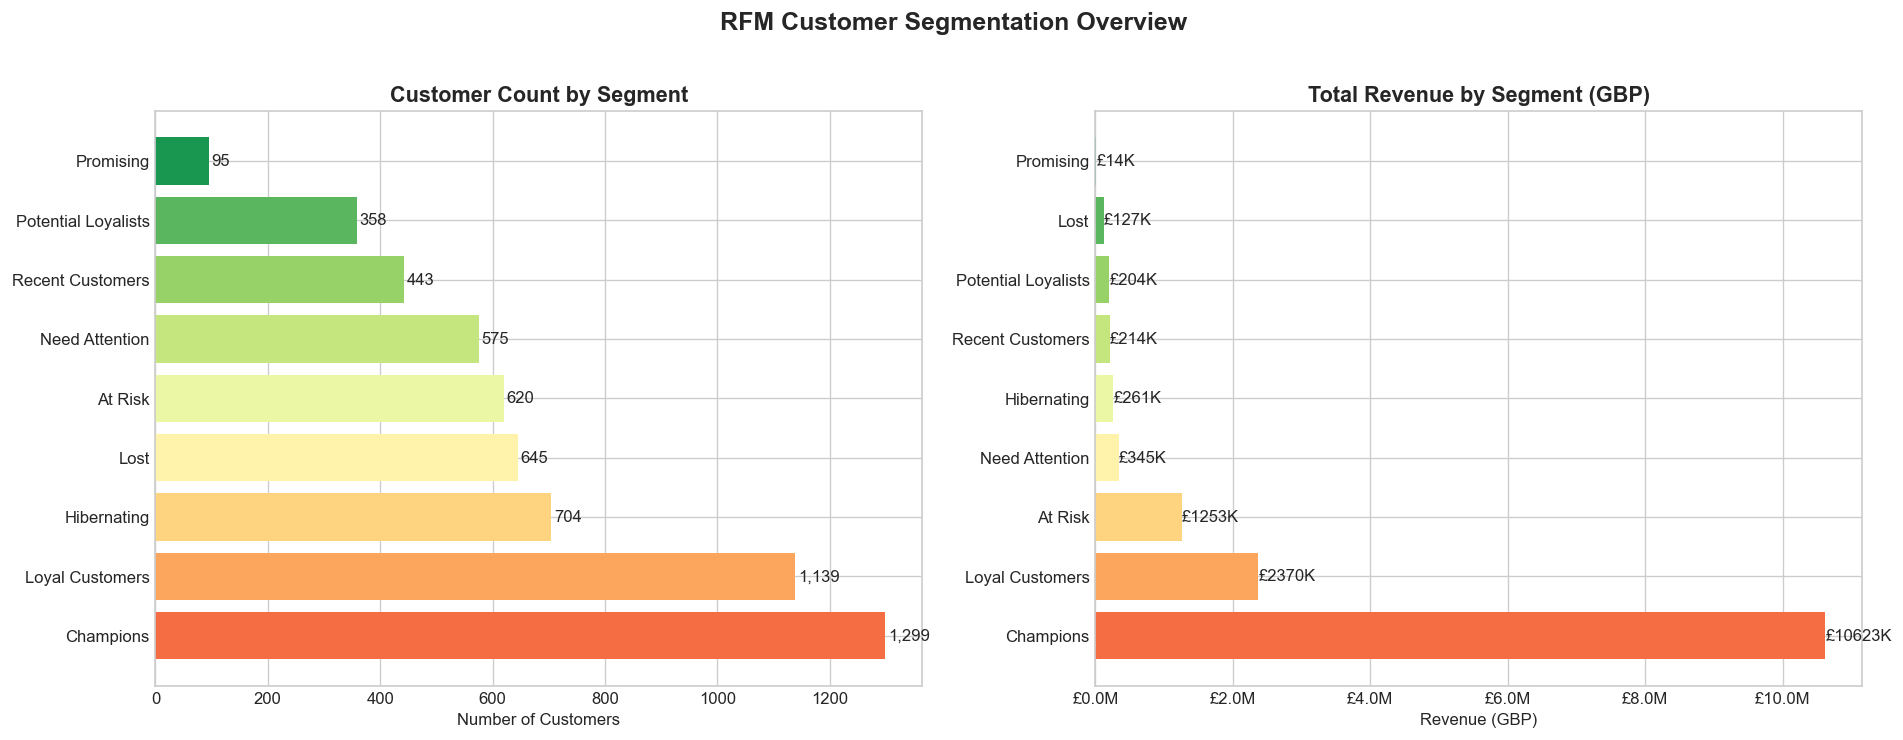

In [22]:
# ─── Segment Distribution Plot ─────────────────────────────
# Visualize how customers are distributed across segments
# This is the first "business-ready" output of the project

segment_counts = rfm['Segment'].value_counts()
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer count per segment
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(segment_counts)))
axes[0].barh(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=10)

# Revenue per segment
colors2 = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(segment_revenue)))
axes[1].barh(segment_revenue.index, segment_revenue.values, color=colors2)
axes[1].set_title('Total Revenue by Segment (GBP)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue (GBP)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for i, v in enumerate(segment_revenue.values):
    axes[1].text(v + 1000, i, f'£{v/1000:.0f}K', va='center', fontsize=10)

plt.suptitle('RFM Customer Segmentation Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ─── Segment Profile Table ─────────────────────────────────
# For each segment: average R, F, M values + customer count + revenue share
# This is what a business stakeholder actually reads
# It answers: WHO are these customers and HOW MUCH do they contribute?

profile = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(1)

profile['Revenue_Share%'] = (profile['Total_Revenue'] / 
                              profile['Total_Revenue'].sum() * 100).round(1)
profile['Customer_Share%'] = (profile['Customers'] / 
                               profile['Customers'].sum() * 100).round(1)

profile = profile.sort_values('Total_Revenue', ascending=False)
print(profile.to_string())

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share%  Customer_Share%
Segment                                                                                                                 
Champions                 1299        20.00          17.10       8177.50    10622564.90           68.90            22.10
Loyal Customers           1139        73.20           5.90       2080.50     2369745.50           15.40            19.40
At Risk                    620       359.80           5.60       2021.10     1253068.60            8.10            10.50
Need Attention             575       413.40           2.10        599.70      344827.60            2.20             9.80
Hibernating                704       277.40           1.30        370.40      260731.30            1.70            12.00
Recent Customers           443        28.10           1.50        483.40      214167.60            1.40             7.50
Potential Loyalists        358  

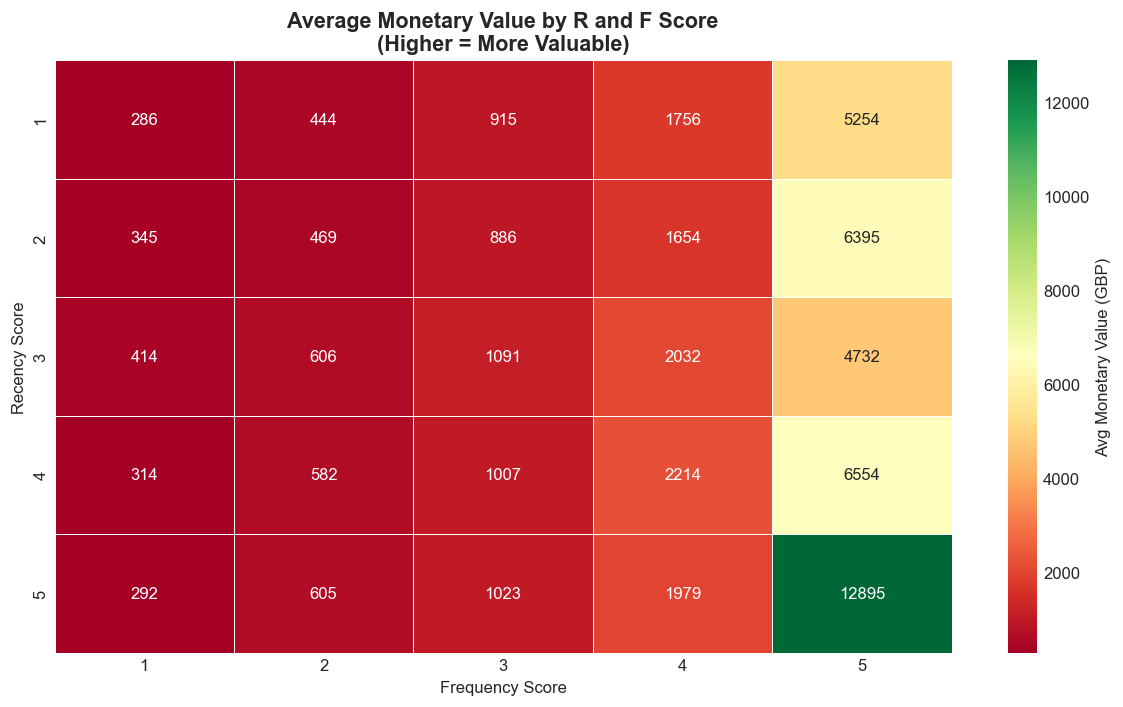

In [23]:
# ─── RFM Heatmap ───────────────────────────────────────────
# Visualize average monetary value across R and F score combinations
# Dark green = high value customers, red = low value
# This reveals which score combinations drive the most revenue

pivot = rfm.pivot_table(index='R_Score', columns='F_Score', 
                         values='Monetary', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg Monetary Value (GBP)'})
plt.title('Average Monetary Value by R and F Score\n(Higher = More Valuable)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.tight_layout()
plt.show()

In [25]:
# ─── Save RFM Table ────────────────────────────────────────
# Save the complete RFM table for use in clustering and dashboard
rfm.to_csv('C:/Users/DELL/rfm-analysis/data/processed/rfm_scores.csv', index=False)

print(f"RFM table saved!")
print(f"Shape: {rfm.shape}")
print(f"\nColumns: {rfm.columns.tolist()}")
rfm.head()

RFM table saved!
Shape: (5878, 10)

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Segment']


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment
0,12346,326,12,522.62,2,5,2,3.05,252,Need Attention
1,12347,2,8,4822.65,5,4,5,4.65,545,Champions
2,12348,75,5,1793.95,3,4,4,3.70,344,Loyal Customers
3,12349,19,4,3612.54,5,3,5,4.30,535,Loyal Customers
4,12350,310,1,309.35,2,1,2,1.65,212,Hibernating


In [31]:
import os
#create the directory if it doesn't exist
os.makedirs('../src/',exist_ok = True)

In [32]:
# ─── Write src/rfm.py ──────────────────────────────────────
rfm_code = '''import pandas as pd
import numpy as np


def calculate_rfm(df: pd.DataFrame, 
                  snapshot_date: pd.Timestamp = None) -> pd.DataFrame:
    """
    Calculate RFM scores for each customer.
    
    Args:
        df: Clean retail dataframe with columns:
            Customer ID, InvoiceDate, Invoice, Revenue
        snapshot_date: Reference date for recency calculation.
                      Defaults to 1 day after last transaction.
    Returns:
        DataFrame with RFM scores and segment labels.
    """
    if snapshot_date is None:
        snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    # Raw RFM values
    rfm = df.groupby("Customer ID").agg(
        Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency = ("Invoice", "nunique"),
        Monetary  = ("Revenue", "sum")
    ).reset_index()

    # Quantile scoring
    rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, 
                              labels=[5,4,3,2,1]).astype(int)
    rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5,
                              labels=[1,2,3,4,5]).astype(int)
    rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5,
                              labels=[1,2,3,4,5]).astype(int)

    # Composite score
    rfm["RFM_Score"] = (rfm["R_Score"] * 0.3 +
                        rfm["F_Score"] * 0.35 +
                        rfm["M_Score"] * 0.35)

    rfm["RFM_Segment"] = (rfm["R_Score"].astype(str) +
                          rfm["F_Score"].astype(str) +
                          rfm["M_Score"].astype(str))

    rfm["Segment"] = rfm.apply(_assign_segment, axis=1)
    return rfm


def _assign_segment(row) -> str:
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:   return "Champions"
    elif r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    elif r >= 4 and f <= 2:            return "Recent Customers"
    elif r >= 3 and f >= 2 and m >= 2: return "Potential Loyalists"
    elif r == 3 and f == 1 and m == 1: return "Promising"
    elif r <= 2 and f >= 3 and m >= 3: return "At Risk"
    elif r <= 2 and f >= 2 and m >= 2: return "Need Attention"
    elif r == 1 and f >= 4 and m >= 4: return "Cannot Lose Them"
    elif r == 1 and f <= 2 and m <= 2: return "Lost"
    else:                              return "Hibernating"
'''

with open('../src/rfm.py', 'w') as f:
    f.write(rfm_code)

print("src/rfm.py created successfully!")

src/rfm.py created successfully!
